In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from model import build_design_matrix, fit_ols
from transformations import geometric_adstock, hill_saturation
from allocation import response, marginal_roi, total_response, neg_total_response, budget_constraint, run_optimisation, build_comparison, make_bounds

In [2]:
df = pd.read_csv("../data/processed/dt_transformed.csv")
df['DATE'] = pd.to_datetime(df['DATE'])

SAT_COLS = [
    'tv_S_adstock_norm_sat',
    'ooh_S_adstock_norm_sat',
    'print_S_adstock_norm_sat',
    'facebook_S_adstock_norm_sat',
    'search_S_adstock_norm_sat',
]

EXACT_WEEK_COLS = [f'is_week_{obs}' for obs in [25, 57, 73, 75, 109, 123]]

CONTROL_COLS = (
    ['competitor_sales_norm', 'is_holiday',
     'is_christmas', 'is_new_year', 'is_easter_monday',
     'is_whit_monday', 'is_labor_day']
    + EXACT_WEEK_COLS
    + ['event1', 'event2',
       'February', 'March', 'May', 'June', 'July', 'August', 'September']
)

X = build_design_matrix(df, SAT_COLS, CONTROL_COLS)
y = df['revenue']
results = fit_ols(X, y)

print(f"Model fitted. R² = {results.rsquared:.4f}")

Model fitted. R² = 0.9862


# STEP 1

In [3]:
MEDIA_COLS = ['tv_S', 'ooh_S', 'print_S', 'facebook_S', 'search_S']

CHANNEL_LABELS = {
    'tv_S': 'TV',
    'ooh_S': 'OOH',
    'print_S': 'Print',
    'facebook_S': 'Facebook',
    'search_S': 'Search',
}

# Hill saturation parameters (from your transformation step)
HILL_PARAMS = {
    'tv_S':       {'decay': 0.60, 'K': 0.50, 'S': 2.5},
    'ooh_S':      {'decay': 0.20, 'K': 0.40, 'S': 2.0},
    'print_S':    {'decay': 0.10, 'K': 0.12, 'S': 1.3},
    'facebook_S': {'decay': 0.09, 'K': 0.09, 'S': 1.1},
    'search_S':   {'decay': 0.05, 'K': 0.05, 'S': 0.5},
}

# OLS coefficient for each saturated channel column
COEFS = {
    'tv_S':       results.params['tv_S_adstock_norm_sat'],
    'ooh_S':      results.params['ooh_S_adstock_norm_sat'],
    'print_S':    results.params['print_S_adstock_norm_sat'],
    'facebook_S': results.params['facebook_S_adstock_norm_sat'],
    'search_S':   results.params['search_S_adstock_norm_sat'],
}

print("Coefficients (£ per unit of saturated normalised spend):")
for ch, beta in COEFS.items():
    print(f"  {CHANNEL_LABELS[ch]:10s}: £{beta:>14,.0f}")

Coefficients (£ per unit of saturated normalised spend):
  TV        : £       303,971
  OOH       : £        86,136
  Print     : £       115,981
  Facebook  : £        32,363
  Search    : £         2,311


In [4]:
# Load the raw data so we can compute actual £ spend
df_raw = pd.read_csv("../data/raw/dt_simulated_weekly.csv")
df_raw = df_raw.sort_values('DATE').reset_index(drop=True)

# For each channel: compute mean weekly spend (£) and the adstock max
# (the normalisation factor used to scale adstocked spend into 0-1)
channel_state = {}

for col in MEDIA_COLS:
    decay = HILL_PARAMS[col]['decay']
    
    raw_spend = df_raw[col].values
    adstock = geometric_adstock(raw_spend, decay)
    
    channel_state[col] = {
        'mean_weekly_spend':  raw_spend.mean(),
        'total_spend':        raw_spend.sum(),
        'adstock_max':        adstock.max(),
        'mean_adstock':       adstock.mean(),
    }

# Print as a table
state_df = pd.DataFrame(channel_state).T
state_df.index = [CHANNEL_LABELS[c] for c in state_df.index]
print(state_df.round(0))

          mean_weekly_spend  total_spend  adstock_max  mean_adstock
TV                  14844.0    3087488.0     182354.0       37036.0
OOH                 43218.0    8989332.0     501341.0       54022.0
Print                3729.0     775556.0      32100.0        4143.0
Facebook             2146.0     446297.0      15424.0        2352.0
Search               5916.0    1230427.0      18681.0        6227.0


In [5]:
rows = []

for col in MEDIA_COLS:
    state = channel_state[col]
    params = HILL_PARAMS[col]
    coef = COEFS[col]
    
    spend = state['mean_weekly_spend']
    decay = params['decay']
    
    current_response = response(
        spend, decay, coef, params['K'], params['S'], state['adstock_max']
    )

    current_roi = current_response / spend if spend > 0 else np.nan

    current_mroi = marginal_roi(
        spend, coef, params['K'], params['S'], state['adstock_max'], decay
    )
    
    rows.append({
        'Channel':         CHANNEL_LABELS[col],
        'Current Spend':   round(spend, 0),
        'Current Response': round(current_response, 0),
        'Current ROI':     round(current_roi, 2),
        'Marginal ROI':    round(current_mroi, 2),
    })

current_df = pd.DataFrame(rows)
print(current_df.to_string(index=False))

 Channel  Current Spend  Current Response  Current ROI  Marginal ROI
      TV        14844.0           29053.0         1.96          4.43
     OOH        43218.0            5828.0         0.13          0.25
   Print         3729.0           60733.0        16.29         10.09
Facebook         2146.0           20768.0         9.68          3.81
  Search         5916.0            1666.0         0.28          0.04


# STEP 2

In [6]:
# Bounds: how far each channel's spend can move from its current level
# We use ±30% of current spend as a default, then clip the lower bound at 0
# (no channel can spend negative money)

# Build the current spend array (in the same order as MEDIA_COLS)
current_spend = np.array([
    channel_state[col]['mean_weekly_spend'] for col in MEDIA_COLS
])


In [7]:
current_total = current_spend.sum()
scenario_specs = [
    {'target_budget': current_total,        'lower_pct': 0.70, 'upper_pct': 1.30, 'label': 'Same budget, ±30% bound'},
    {'target_budget': current_total * 1.20, 'lower_pct': 0.70, 'upper_pct': 1.30, 'label': 'Same budget +20%, ±30% bound'},
    {'target_budget': current_total * 0.80, 'lower_pct': 0.70, 'upper_pct': 1.30, 'label': 'Same budget -20%, ±30% bound'},
]

# scenario_specs = [
#     {'target_budget': 70000, 'lower_pct': 0.70, 'upper_pct': 1.30, 'label': 'we have 70k'}
# ]

scenarios = []
for spec in scenario_specs:
    bounds = make_bounds(current_spend, spec['lower_pct'], spec['upper_pct'])
    
    result = run_optimisation(
        target_budget=spec['target_budget'],
        scenario_label=spec['label'],
        current_spend=current_spend,
        bounds=bounds,
        media_cols=MEDIA_COLS,
        coefs=COEFS,
        hill_params=HILL_PARAMS,
        channel_state=channel_state,
    )
    scenarios.append(result)

for s in scenarios:
    print(f"{s['scenario']:15s} | converged: {s['success']} | response: £{s['response']:,.0f}")

Same budget, ±30% bound | converged: True | response: £151,007
Same budget +20%, ±30% bound | converged: True | response: £154,655
Same budget -20%, ±30% bound | converged: True | response: £123,320


In [8]:
for s in scenarios:
    comp_df, summary = build_comparison(
        scenario=s,
        current_spend=current_spend,
        media_cols=MEDIA_COLS,
        coefs=COEFS,
        hill_params=HILL_PARAMS,
        channel_state=channel_state,
        channel_labels=CHANNEL_LABELS,
    )
    
    print(f"\n{'='*70}")
    print(f"SCENARIO: {summary['scenario']} (target: £{summary['target_budget']:,.0f}/week)")
    print(f"{'='*70}")
    print(comp_df.to_string(index=False))
    
    print(f"\nTotal response (current):    £{summary['current_total_response']:>10,.0f}")
    print(f"Total response (optimised):  £{summary['new_total_response']:>10,.0f}")
    print(f"Uplift:                      £{summary['uplift']:>10,.0f}  ({summary['uplift_pct']:+.1f}%)")
    print(f"Total spend check:           £{summary['total_spend_check']:>10,.0f}")


SCENARIO: Same budget, ±30% bound (target: £69,851/week)
 Channel  Current Spend  Recommended Spend  Change %  Current Response  New Response
      TV        14844.0            19297.0      30.0           29053.0       51426.0
     OOH        43218.0            38777.0     -10.3            5828.0        4755.0
   Print         3729.0             4847.0      30.0           60733.0       70429.0
Facebook         2146.0             2789.0      30.0           20768.0       22817.0
  Search         5916.0             4141.0     -30.0            1666.0        1580.0

Total response (current):    £   118,048
Total response (optimised):  £   151,007
Uplift:                      £    32,959  (+27.9%)
Total spend check:           £    69,851

SCENARIO: Same budget +20%, ±30% bound (target: £83,822/week)
 Channel  Current Spend  Recommended Spend  Change %  Current Response  New Response
      TV        14844.0            19297.0      30.0           29053.0       51426.0
     OOH        43218.0 

In [9]:
summary_rows = []
for s in scenarios:
    _, summary = build_comparison(
        scenario=s,
        current_spend=current_spend,
        media_cols=MEDIA_COLS,
        coefs=COEFS,
        hill_params=HILL_PARAMS,
        channel_state=channel_state,
        channel_labels=CHANNEL_LABELS,
    )
    summary_rows.append({
        'Scenario':       summary['scenario'],
        'Target Budget':  round(summary['target_budget'], 0),
        'New Response':   round(summary['new_total_response'], 0),
        'Uplift £':       round(summary['uplift'], 0),
        'Uplift %':       round(summary['uplift_pct'], 1),
    })

executive_summary = pd.DataFrame(summary_rows)
print(executive_summary.to_string(index=False))

                    Scenario  Target Budget  New Response  Uplift £  Uplift %
     Same budget, ±30% bound        69851.0      151007.0   32959.0      27.9
Same budget +20%, ±30% bound        83822.0      154655.0   36607.0      31.0
Same budget -20%, ±30% bound        55881.0      123320.0    5272.0       4.5


# STEP 3

## Total Budget Optimization Result

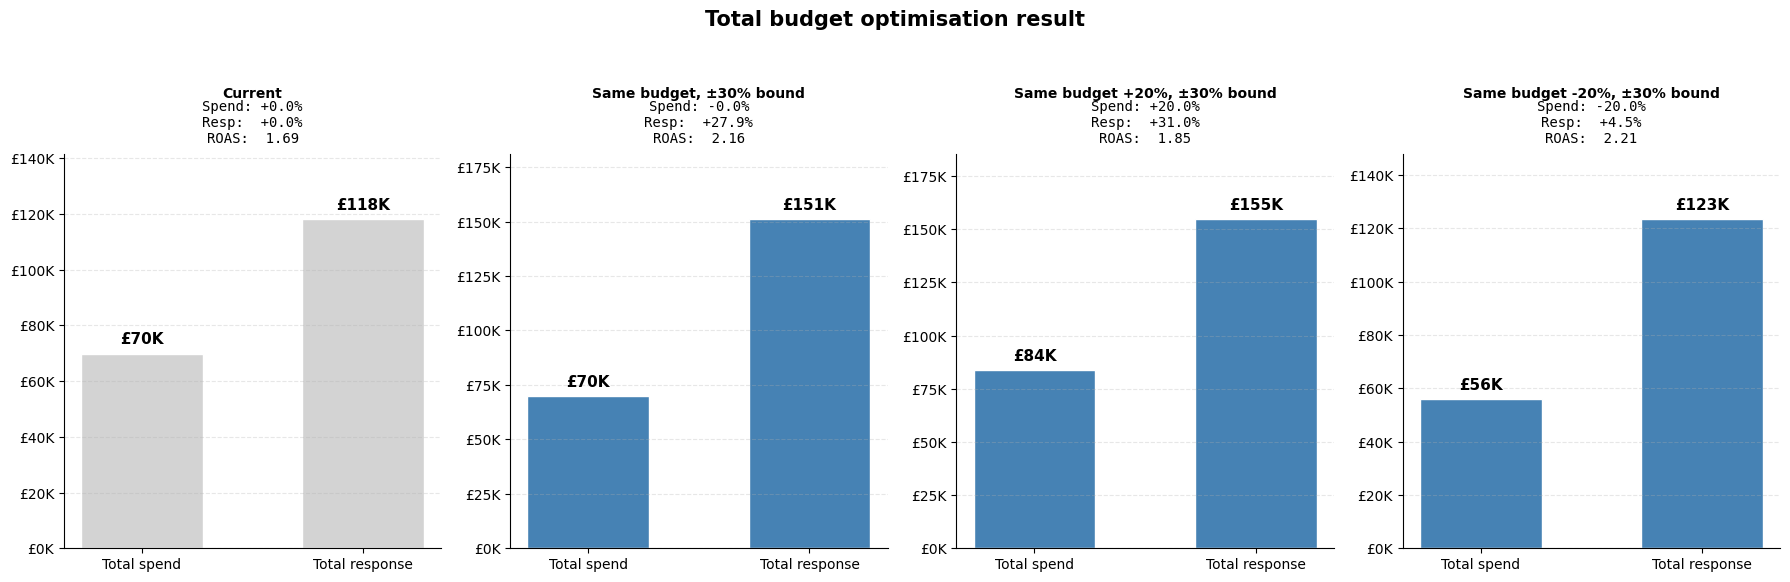

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Compute current baseline metrics
current_total_spend_val = current_spend.sum()
current_total_resp = total_response(
    current_spend, MEDIA_COLS, COEFS, HILL_PARAMS, channel_state
)
current_roas = current_total_resp / current_total_spend_val

# Build a list with current as the first "scenario" plus the three optimised ones
panels = [
    {
        'label':           'Current',
        'total_spend':     current_total_spend_val,
        'total_response':  current_total_resp,
        'roas':            current_roas,
        'spend_change_pct':    0.0,
        'response_change_pct': 0.0,
        'colour':          'lightgrey',
    }
]

for s in scenarios:
    s_spend = s['spend'].sum()
    s_resp = s['response']
    s_roas = s_resp / s_spend
    panels.append({
        'label':           s['scenario'],
        'total_spend':     s_spend,
        'total_response':  s_resp,
        'roas':            s_roas,
        'spend_change_pct':    (s_spend - current_total_spend_val) / current_total_spend_val * 100,
        'response_change_pct': (s_resp - current_total_resp) / current_total_resp * 100,
        'colour':          'steelblue',
    })

# Set up the figure: 1 row, 4 columns (current + 3 scenarios)
fig, axes = plt.subplots(1, len(panels), figsize=(18, 5.5), sharey=False)

for ax, panel in zip(axes, panels):
    # Two bars: total spend and total response
    bar_labels = ['Total spend', 'Total response']
    bar_values = [panel['total_spend'], panel['total_response']]
    
    bars = ax.bar(bar_labels, bar_values, color=panel['colour'],
                  edgecolor='white', width=0.55)
    
    # Annotate each bar with its £ value
    for bar, value in zip(bars, bar_values):
        ax.annotate(f'£{value/1000:.0f}K',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Title: scenario label
    ax.set_title(panel['label'], fontsize=10, fontweight='bold', pad=40)
    
    # Summary text above the title (Robyn style: Spend %, Resp %, ROAS)
    summary_text = (
        f"Spend: {panel['spend_change_pct']:+.1f}%\n"
        f"Resp:  {panel['response_change_pct']:+.1f}%\n"
        f"ROAS:  {panel['roas']:.2f}"
    )
    ax.text(0.5, 1.02, summary_text, transform=ax.transAxes,
            ha='center', va='bottom', fontsize=10,
            family='monospace')
    
    # Style
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1000:.0f}K'))
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, max(bar_values) * 1.2)

fig.suptitle('Total budget optimisation result', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## Budget allocation per channel (heatmap)

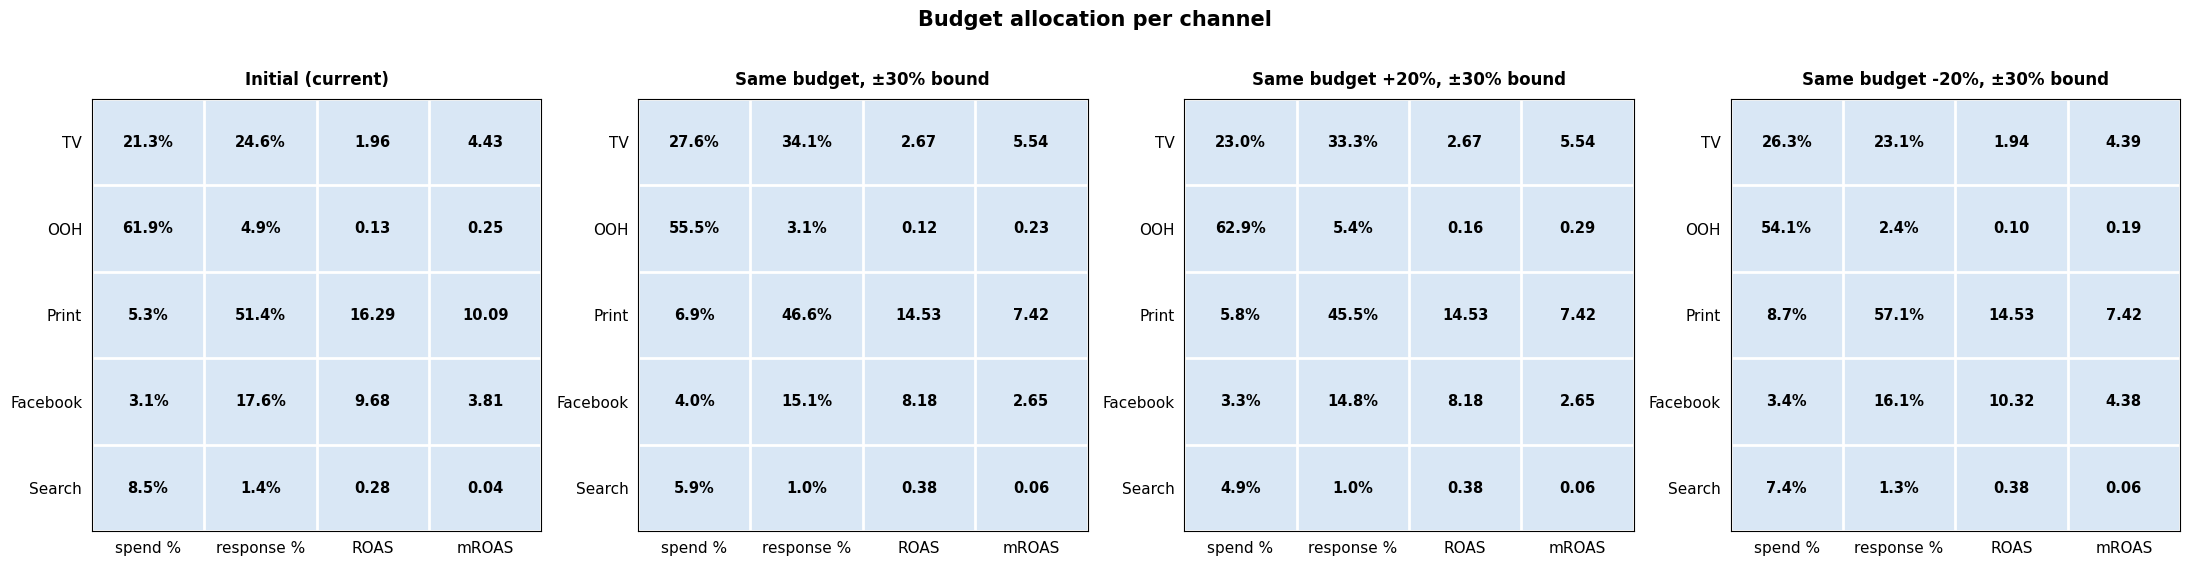

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def build_heatmap_data(spend_array, label):
    """Return row labels, matrix, and display strings for a given spend allocation."""
    total_spend_val = spend_array.sum()
    
    rows = []
    for i, col in enumerate(MEDIA_COLS):
        spend = spend_array[i]
        params = HILL_PARAMS[col]
        state = channel_state[col]
        coef = COEFS[col]
        
        channel_response = response(
            spend=spend, decay=params['decay'], coef=coef,
            K=params['K'], S=params['S'], adstock_max=state['adstock_max'],
        )
        channel_mroi = marginal_roi(
            spend=spend, coef=coef, K=params['K'], S=params['S'],
            adstock_max=state['adstock_max'], decay=params['decay'],
        )
        
        rows.append({
            'Channel':  CHANNEL_LABELS[col],
            'spend':    spend,
            'response': channel_response,
            'roas':     channel_response / spend if spend > 0 else 0,
            'mroas':    channel_mroi,
        })
    
    df = pd.DataFrame(rows)
    total_response_val = df['response'].sum()
    df['spend_pct']    = df['spend'] / total_spend_val * 100
    df['response_pct'] = df['response'] / total_response_val * 100
    
    matrix = df[['spend_pct', 'response_pct', 'roas', 'mroas']].values
    
    display = np.empty_like(matrix, dtype=object)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if j < 2:
                display[i, j] = f'{matrix[i, j]:.1f}%'
            else:
                display[i, j] = f'{matrix[i, j]:.2f}'
    
    return df['Channel'].values, matrix, display


# Build a list with Current first, then the three optimised scenarios
panels = [
    {'label': 'Initial (current)', 'spend': current_spend},
]

for s in scenarios:
    panels.append({
        'label': s['scenario'],
        'spend': s['spend'],
    })

# Set up: 1 row, 4 columns of heatmaps (Initial + 3 scenarios)
fig, axes = plt.subplots(1, len(panels), figsize=(22, 5.5))

column_labels = ['spend %', 'response %', 'ROAS', 'mROAS']

for ax, panel in zip(axes, panels):
    row_labels, matrix, display_strings = build_heatmap_data(
        panel['spend'], panel['label']
    )
    
    # Uniform pale blue background
    uniform_colour = np.ones_like(matrix) * 0.15
    ax.imshow(uniform_colour, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    
    # Ticks and labels
    ax.set_xticks(np.arange(len(column_labels)))
    ax.set_xticklabels(column_labels, fontsize=11)
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=11)
    
    # Gridlines
    ax.set_xticks(np.arange(matrix.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(matrix.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which='minor', color='white', linewidth=2)
    ax.tick_params(which='minor', bottom=False, left=False)
    
    # Cell text
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, display_strings[i, j],
                    ha='center', va='center', color='black',
                    fontsize=10.5, fontweight='bold')
    
    ax.set_title(panel['label'], fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(which='major', top=False, bottom=False, left=False, right=False)

fig.suptitle('Budget allocation per channel', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Simulated response curves

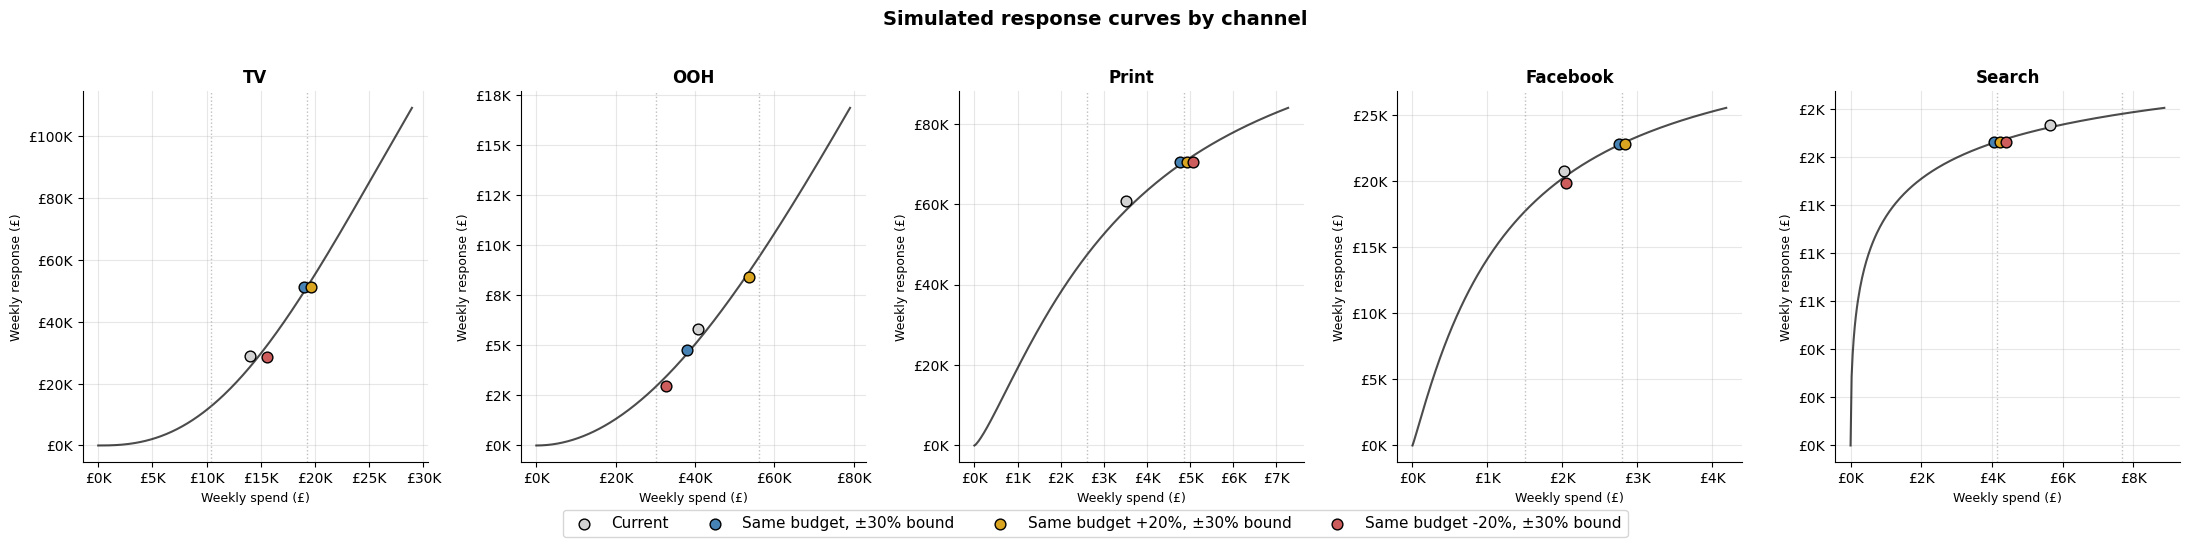

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Small horizontal nudge per scenario so overlapping dots stay visible
# (expressed as a fraction of each channel's x-axis range)
NUDGE_FRACTIONS = [-0.03, -0.01, 0.01, 0.03]

# Define colours and labels for the four dot types
DOT_STYLES = [
    {'label': 'Current',                    'spend_array': current_spend,        'colour': 'lightgrey'},
    {'label': scenarios[0]['scenario'],     'spend_array': scenarios[0]['spend'], 'colour': 'steelblue'},
    {'label': scenarios[1]['scenario'],     'spend_array': scenarios[1]['spend'], 'colour': 'goldenrod'},
    {'label': scenarios[2]['scenario'],     'spend_array': scenarios[2]['spend'], 'colour': 'indianred'},
]

# Set up: 1 row, 5 columns
fig, axes = plt.subplots(1, len(MEDIA_COLS), figsize=(22, 5))

for ax, col, channel_idx in zip(axes, MEDIA_COLS, range(len(MEDIA_COLS))):
    params = HILL_PARAMS[col]
    state = channel_state[col]
    coef = COEFS[col]
    label = CHANNEL_LABELS[col]
    current = current_spend[channel_idx]
    
    # Spend range for the curve: from 0 to a bit beyond the largest dot
    largest_spend = max(s['spend_array'][channel_idx] for s in DOT_STYLES)
    upper_view = largest_spend * 1.5
    spend_range = np.linspace(0, upper_view, 300)
    x_range = upper_view  # used to scale nudges
    
    # Compute response at each spend level
    response_values = np.array([
        response(
            spend=s, decay=params['decay'], coef=coef,
            K=params['K'], S=params['S'], adstock_max=state['adstock_max'],
        )
        for s in spend_range
    ])
    
    # Plot the curve
    ax.plot(spend_range, response_values, color='black', linewidth=1.5, alpha=0.7)
    
    # Plot all four dots with a small horizontal nudge each
    for style, nudge_frac in zip(DOT_STYLES, NUDGE_FRACTIONS):
        dot_spend = style['spend_array'][channel_idx]
        nudged_spend = dot_spend + nudge_frac * x_range
        dot_resp = response(
            spend=dot_spend, decay=params['decay'], coef=coef,
            K=params['K'], S=params['S'], adstock_max=state['adstock_max'],
        )
        ax.scatter([nudged_spend], [dot_resp], color=style['colour'],
                   s=60, edgecolor='black', linewidth=1, zorder=5,
                   label=style['label'])
    
    # Vertical dotted lines at the bounds (using current spend ±30%)
    lower_bound = current * 0.7
    upper_bound = current * 1.3
    ax.axvline(lower_bound, color='grey', linestyle=':', linewidth=1, alpha=0.5)
    ax.axvline(upper_bound, color='grey', linestyle=':', linewidth=1, alpha=0.5)
    
    # Style
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Weekly spend (£)', fontsize=9)
    ax.set_ylabel('Weekly response (£)', fontsize=9)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1000:.0f}K'))
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# One legend for the whole figure, placed below the panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=11,
           bbox_to_anchor=(0.5, -0.05))

fig.suptitle('Simulated response curves by channel', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()